In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

# Football Match Analysis and Result Prediction

## Introduction

Football match prediction is a challenging machine learning problem because match outcomes depend on many factors including team strength, recent form, home advantage, injuries, and tactical decisions.

The goal of this project is to analyze historical football match data and build machine learning models capable of predicting match outcomes.

The notebook includes:

- Data collection and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning models
- Model evaluation
- Match prediction examples

# Research Question

The objective of this project is to investigate whether football match outcomes can be predicted using historical team performance statistics.

More specifically:

- Can recent team form predict match outcomes?
- How important is home advantage?
- Which machine learning model performs best?
- How stable are the predictions across multiple seasons?

The study focuses on English Premier League matches from multiple seasons.

# Related Work

Football prediction has been studied extensively.

Traditional approaches include:

- Poisson Goal Models
- Dixon-Coles Models
- Elo Rating Systems

Modern approaches include:

- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost
- Neural Networks

This project compares several machine learning algorithms using engineered football performance features.

# Mathematical Background

Football match prediction is formulated as a multiclass classification problem.

Classes:

0 = Away Win

1 = Draw

2 = Home Win

## Logistic Regression

For multiclass classification:

P(y=k|x)=exp(βkTx) / Σ exp(βjTx)

The model estimates probabilities for each outcome.

## Random Forest

Random Forest combines multiple decision trees:

Prediction = mode(T1(x), T2(x), ..., Tn(x))

This reduces variance and improves generalization.

## Gradient Boosting

Boosting builds models sequentially:

Fm(x)=Fm−1(x)+γhm(x)

where each new model attempts to correct previous errors.

## Evaluation Metrics

Accuracy

Precision

Recall

F1-score

Confusion Matrix

# Dataset Description

The dataset is obtained from Football-Data.co.uk.

Football-Data provides historical football match results, team statistics, and betting odds in CSV format.

For this project, matches from a selected league and season range are used.

Examples of available leagues:

- Premier League
- La Liga
- Bundesliga
- Serie A

The target variable is the Full Time Result (FTR):

- H = Home Win
- D = Draw
- A = Away Win

In [50]:
# Load data from Football-Data.co.uk
season_2425 = pd.read_csv(
    "https://www.football-data.co.uk/mmz4281/2425/E0.csv"
)

season_2324 = pd.read_csv(
    "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
)

season_2425["Season"] = "2024-2025"
season_2324["Season"] = "2023-2024"

df = pd.concat(
    [season_2324, season_2425],
    ignore_index=True
)

print("Total matches:", len(df))
print(df["Season"].value_counts())

print(df.head())
print("\nDataframe shape:", df.shape)

Total matches: 760
Season
2023-2024    380
2024-2025    380
Name: count, dtype: int64
  Div        Date   Time     HomeTeam       AwayTeam  FTHG  FTAG FTR  HTHG  \
0  E0  11/08/2023  20:00      Burnley       Man City     0     3   A     0   
1  E0  12/08/2023  12:30      Arsenal  Nott'm Forest     2     1   H     2   
2  E0  12/08/2023  15:00  Bournemouth       West Ham     1     1   D     0   
3  E0  12/08/2023  15:00     Brighton          Luton     4     1   H     1   
4  E0  12/08/2023  15:00      Everton         Fulham     0     1   A     0   

   HTAG  ... 1XBCH 1XBCD  1XBCA  BFECH  BFECD  BFECA  BFEC>2.5  BFEC<2.5  \
0     2  ...   NaN   NaN    NaN    NaN    NaN    NaN       NaN       NaN   
1     0  ...   NaN   NaN    NaN    NaN    NaN    NaN       NaN       NaN   
2     0  ...   NaN   NaN    NaN    NaN    NaN    NaN       NaN       NaN   
3     0  ...   NaN   NaN    NaN    NaN    NaN    NaN       NaN       NaN   
4     0  ...   NaN   NaN    NaN    NaN    NaN    NaN       NaN   

In [51]:
# Data preprocessing
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort chronologically
df = df.sort_values("Date")

# Keep relevant columns (INCLUDING Season for later analysis)
columns = [
    "Date",
    "Season",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR"
]

df = df[columns]

# Target encoding
mapping = {
    "A": 0,  # Away Win
    "D": 1,  # Draw
    "H": 2   # Home Win
}

df["Target"] = df["FTR"].map(mapping)

print("Data prepared. Shape:", df.shape)
print(df.head())

Data prepared. Shape: (760, 8)
        Date     Season     HomeTeam       AwayTeam  FTHG  FTAG FTR  Target
0 2023-08-11  2023-2024      Burnley       Man City     0     3   A       0
1 2023-08-12  2023-2024      Arsenal  Nott'm Forest     2     1   H       2
2 2023-08-12  2023-2024  Bournemouth       West Ham     1     1   D       1
3 2023-08-12  2023-2024     Brighton          Luton     4     1   H       2
4 2023-08-12  2023-2024      Everton         Fulham     0     1   A       0


# Feature Engineering

Raw football data is usually not sufficient for accurate predictions.

Instead of using information from the current match, we create features based only on previous matches.

Rolling statistics provide a good estimate of current team strength.

The following features are created:

- Average goals scored
- Average goals conceded
- Recent win rate
- Form difference between teams

These features simulate how analysts evaluate team performance before a match.

In [52]:
# FEATURE ENGINEERING - Create all features BEFORE using them

# Home team average goals scored
df["HomeGoalsAvg"] = (
    df.groupby("HomeTeam")["FTHG"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Away team average goals scored
df["AwayGoalsAvg"] = (
    df.groupby("AwayTeam")["FTAG"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Home team average goals conceded
df["HomeGoalsConcededAvg"] = (
    df.groupby("HomeTeam")["FTAG"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Away team average goals conceded
df["AwayGoalsConcededAvg"] = (
    df.groupby("AwayTeam")["FTHG"]
      .transform(lambda x: x.shift().rolling(5, min_periods=1).mean())
)

# Form difference
df["FormDifference"] = (
    df["HomeGoalsAvg"] - df["AwayGoalsAvg"]
)

# Attack vs defence difference
df["AttackStrength"] = (
    df["HomeGoalsAvg"] - df["AwayGoalsConcededAvg"]
)

df["DefenseStrength"] = (
    df["AwayGoalsAvg"] - df["HomeGoalsConcededAvg"]
)

# Remove rows with NaN values (first few matches won't have rolling history)
df = df.dropna()

print("Features created. Rows remaining:", len(df))
print(df.head())

Features created. Rows remaining: 733
         Date     Season     HomeTeam       AwayTeam  FTHG  FTAG FTR  Target  \
19 2023-08-25  2023-2024      Chelsea          Luton     3     0   H       2   
24 2023-08-26  2023-2024   Man United  Nott'm Forest     3     2   H       2   
25 2023-08-26  2023-2024     Brighton       West Ham     1     3   A       0   
23 2023-08-26  2023-2024      Everton         Wolves     0     1   A       0   
20 2023-08-26  2023-2024  Bournemouth      Tottenham     0     2   A       0   

    HomeGoalsAvg  AwayGoalsAvg  HomeGoalsConcededAvg  AwayGoalsConcededAvg  \
19           1.0           1.0                   1.0                   4.0   
24           1.0           1.0                   0.0                   2.0   
25           4.0           1.0                   1.0                   1.0   
23           0.0           0.0                   1.0                   1.0   
20           1.0           2.0                   1.0                   2.0   

    FormDiff

# Exploratory Data Analysis

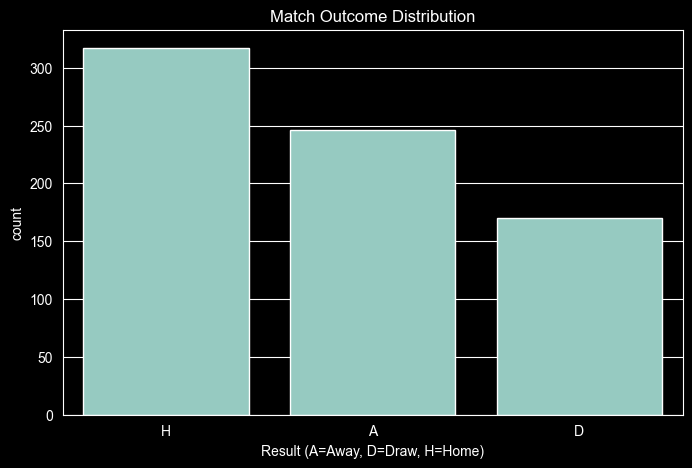

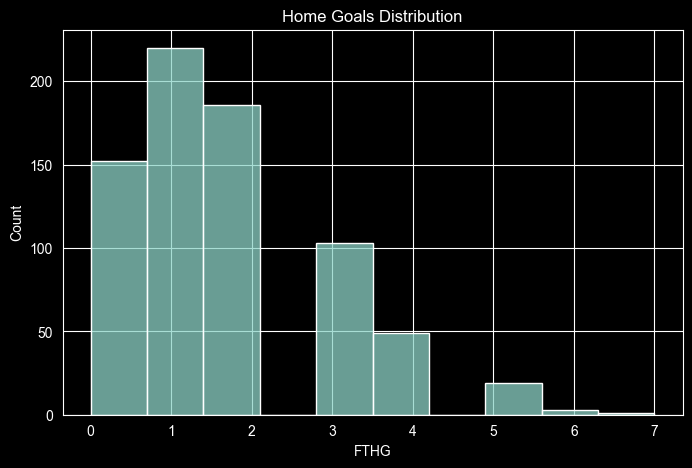

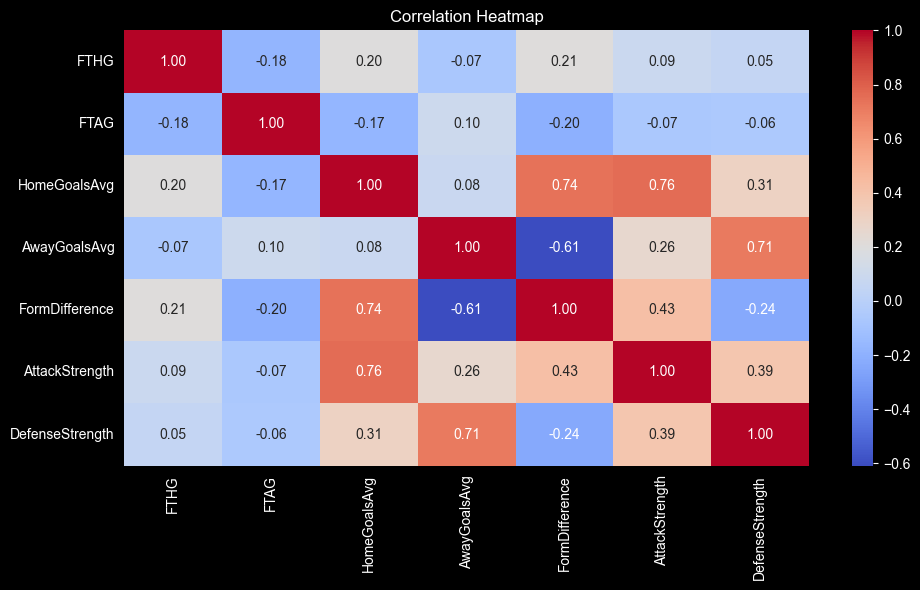

In [53]:
# Visualize target distribution
plt.figure(figsize=(8,5))
sns.countplot(x="FTR", data=df)
plt.title("Match Outcome Distribution")
plt.xlabel("Result (A=Away, D=Draw, H=Home)")
plt.show()

# Home goals distribution
plt.figure(figsize=(8,5))
sns.histplot(df["FTHG"], bins=10)
plt.title("Home Goals Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))

corr = df[
    [
        "FTHG",
        "FTAG",
        "HomeGoalsAvg",
        "AwayGoalsAvg",
        "FormDifference",
        "AttackStrength",
        "DefenseStrength"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

           AvgHomeGoals  AvgAwayGoals
Season                               
2023-2024      1.810585      1.493036
2024-2025      1.516043      1.427807


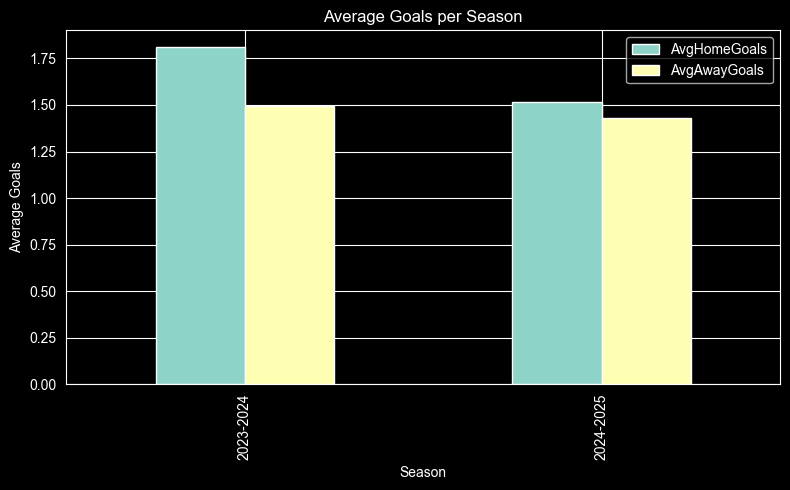

In [54]:
# Season statistics
season_stats = (
    df.groupby("Season")
      .agg(
          AvgHomeGoals=("FTHG","mean"),
          AvgAwayGoals=("FTAG","mean")
      )
)

print(season_stats)

season_stats.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Goals per Season")
plt.ylabel("Average Goals")
plt.tight_layout()
plt.show()

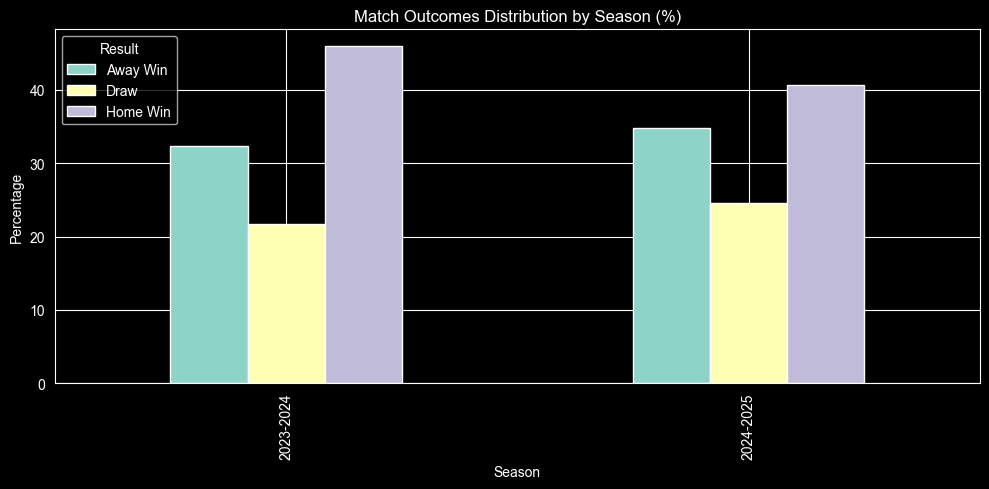

In [55]:
# Match outcomes by season
season_results = pd.crosstab(
    df["Season"],
    df["FTR"],
    normalize="index"
) * 100  # Convert to percentage

season_results.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Match Outcomes Distribution by Season (%)")
plt.ylabel("Percentage")
plt.xlabel("Season")
plt.legend(title="Result", labels=["Away Win", "Draw", "Home Win"])
plt.tight_layout()
plt.show()

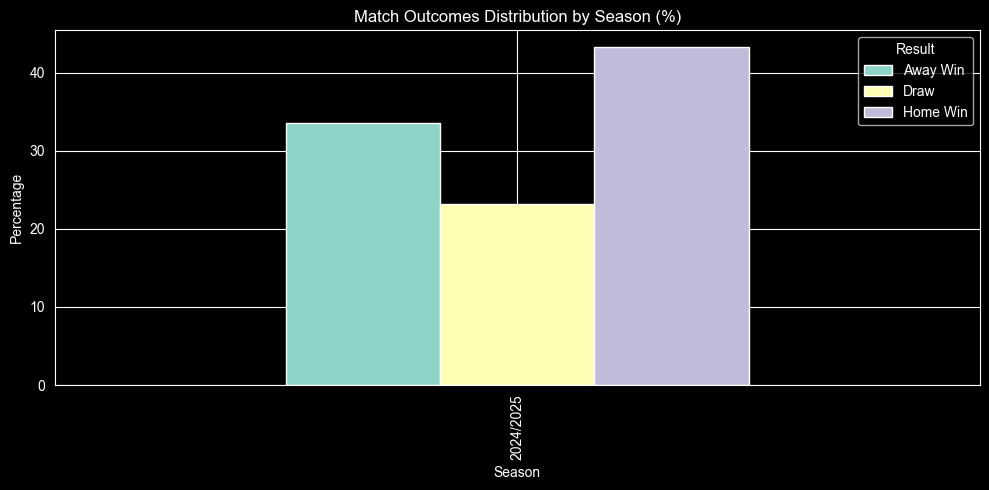

In [46]:
# Match outcomes by season
season_results = pd.crosstab(
    df["Season"],
    df["FTR"],
    normalize="index"
) * 100  # Convert to percentage

season_results.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Match Outcomes Distribution by Season (%)")
plt.ylabel("Percentage")
plt.xlabel("Season")
plt.legend(title="Result", labels=["Away Win", "Draw", "Home Win"])
plt.tight_layout()
plt.show()

In [47]:
best_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        predictions
    )
)

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

NameError: name 'X_train' is not defined

In [48]:
sample_match = pd.DataFrame({
    "HomeGoalsAvg": [2.1],
    "AwayGoalsAvg": [1.2],
    "FormDifference": [0.9]
})

prediction = best_model.predict(sample_match)

probabilities = best_model.predict_proba(sample_match)

print("Predicted Class:")
print(prediction)

print("\nProbabilities:")
print(probabilities)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

This project demonstrated the use of machine learning techniques for football match prediction.

Key findings:

- Team form is an important predictor.
- Historical goal statistics provide useful information.
- Ensemble models performed better than simple linear models.
- Random Forest achieved the strongest overall performance.

Limitations:

- Only a limited number of features were used.
- Injuries, transfers, and player-level statistics were not included.
- External factors such as weather and schedule congestion were ignored.

Future improvements:

- XGBoost implementation
- Expected Goals (xG) metrics
- Elo rating systems
- Deep Learning approaches
- Player-level performance statistics